In [ ]:
import matplotlib.pyplot as plt
import shutil
import numpy as np
from pathlib import Path
from scipy import integrate

fontsi = 15
if shutil.which("latex") is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']  # explicitly specify CM
plt.rc('image', interpolation='none')

tmin = 2.0
tmax = 100.0


## Covariance matrix ordering

The covariance matrix has shape **(840 × 840)** and covers COSEBIs E-modes and B-modes for **6 tomographic bins** and **20 spatial modes (n = 1 … 20)**.

The 840 rows/columns are ordered as follows:

### Outer structure — two blocks of 420

| Rows | Component |
|------|-----------|
| 0 – 419 | E_n (E-mode COSEBIs) |
| 420 – 839 | B_n (B-mode COSEBIs) |

### Inner structure — each block of 420

Within each block the elements are ordered by **tomographic pair first, mode second**:

- Tomographic pairs run over all **21 unique combinations** (i ≤ j, 1-based):
  (1,1), (1,2), (1,3), (1,4), (1,5), (1,6), (2,2), (2,3), …, (6,6)
- For each pair, the **20 modes** are stored contiguously: n = 1, 2, …, 20

So the flat index within one block is:

```
idx = pair_index * 20 + (n - 1)
```

where `pair_index` runs from 0 to 20 following the (i ≤ j) ordering above.

### Full index table 

| Index range | Tomo pair (i,j) | Modes |
|-------------|-----------------|-------|
| 0 – 19 | (1,1) | 1–20 |
| 20 – 39 | (1,2) | 1–20 |
| … | … | … |
| 100 – 119 | (1,6) | 1–20 |
| 120 – 139 | (2,2) | 1–20 |
| … | … | … |
| 400 – 419 | (6,6) | 1–20 |
| 420 – 839 | same order, B_n | 1–20 |

In [109]:
data_dir = Path("./../data")
cov = np.loadtxt(data_dir / f"euclid_dr1_cosmic_shear_covariance_matrix_{tmin}_to_{tmax}_cosebis.mat",
                 comments="#")

## Example data

The files `Cell_kappakappa.ascii` an example set of convergence power spectra for 6 tomographic bins, used here solely to illustrate how to compute COSEBIs from a given convergence power spectrum

In [110]:


raw = np.loadtxt(data_dir / "Cell_kappakappa.ascii")

ell_values = np.unique(raw[:, 0])   
n_ell = len(ell_values)             
n_tomo = 6

Cell = np.zeros((n_tomo, n_tomo, n_ell))
for row in raw:
    i = int(row[1]) - 1   # convert 1-based → 0-based
    j = int(row[2]) - 1
    k = np.searchsorted(ell_values, row[0])
    Cell[i, j, k] = row[3]



## Computing COSEBIs from C_ℓ

The COSEBIs E-modes are defined as (Schneider et al. 2010, eq. 16):

$$E_n^{ij} = \frac{1}{2\pi} \int_0^\infty \mathrm{d}\ell\; \ell\; W_n(\ell)\; C_\ell^{\kappa\kappa}(i,j)$$

where W_n(ℓ) is the Fourier-space COSEBIs filter for mode n, computed from T_+(θ) via `get_cosebis.py` and stored in `benchmarks_cosebis/`.

The cell below:
1. **Loads all W_n(ℓ) basis functions** from the benchmark files for the configured `tmin`/`tmax` and up to 20 modes.
2. **Interpolates each C_ℓ^κκ(i,j)** in log-log space with a cubic spline so it can be evaluated on the ℓ grid of W_n.
3. **Integrates** ℓ W_n(ℓ) C_ℓ(i,j) / π over ℓ using Simpson's rule to obtain E_n^ij for all tomographic pairs (i,j) and all modes n, exploiting the symmetry E_n^ij = E_n^ji.

The result is stored in `En` with shape `(n_tomo, n_tomo, n_modes)`.

In [111]:
def simpson_error(integrand, x):
    """

    Computes the integral on the full grid and on every other point (half grid).
    For Simpson's rule the error scales as O(h^4), so the error can be estimated as

        eps ~ |I_full - I_half| / (2^4 - 1) = |I_full - I_half| / 15

    Parameters
    ----------
    integrand : np.ndarray
        Integrand values on x.
    x : np.ndarray
        Integration variable (need not be uniform).

    Returns
    -------
    I_full : float
        Simpson integral on the full grid.
    error : float
        Richardson-extrapolated error estimate.
    """
    I_full = integrate.simpson(integrand, x=x)
    # subsample every other point; ensure even number of intervals for Simpson
    half = integrand[::2]
    x_half = x[::2]
    if len(x_half) % 2 == 0:   # need odd number of points for Simpson
        half = half[:-1]
        x_half = x_half[:-1]
    I_half = integrate.simpson(half, x=x_half)
    return I_full, abs(I_full - I_half) / 15.0

In [112]:
import numpy as np
import glob
from pathlib import Path
from scipy.interpolate import UnivariateSpline


benchmarks_dir = Path("./../benchmarks_cosebis")
arcmintorad = 1. / 60 * np.pi / 180


tp_files = sorted(benchmarks_dir.glob(f"Tp_benchmark_{tmin}_{tmax}_mode_*.txt"))
tm_files = sorted(benchmarks_dir.glob(f"Tm_benchmark_{tmin}_{tmax}_mode_*.txt"))



well_files = sorted(benchmarks_dir.glob(f"Well_{tmin}_{tmax}_mode_*.txt"))
Well_data = [np.loadtxt(f) for f in well_files]

well_files = sorted(benchmarks_dir.glob(f"Well_{tmin}_{tmax}_mode_*.txt"))

well_files_acc = sorted(benchmarks_dir.glob(f"high_acc_Well_{tmin}_{tmax}_mode_*.txt"))



Tp_data = [np.loadtxt(f) for f in tp_files]
Tm_data = [np.loadtxt(f) for f in tm_files]
Well_data = [np.loadtxt(f) for f in well_files]
Well_data_acc = [np.loadtxt(f) for f in well_files_acc]


En = np.zeros((n_tomo, n_tomo, 20))  
En_error = np.zeros((n_tomo, n_tomo, 20))

for i in range(20):
    Well_i = Well_data[i][:, 1]
    ell_i = Well_data[i][:, 0]    
    for i_tomo in range(n_tomo):
        for j_tomo in range(i_tomo, n_tomo):
            Cell_ij = Cell[i_tomo, j_tomo, :]
            log_cell = np.log(Cell_ij)
            spl = UnivariateSpline(np.log(ell_values), log_cell, s=0, ext=0, k =3)

            integrand = ell_i * Well_i * np.exp(spl(np.log(ell_i)))/np.pi
           # En[i_tomo, j_tomo, i] = integrate.simpson(integrand, x = ell_i)
            En[i_tomo, j_tomo, i], En_error[i_tomo, j_tomo, i] = simpson_error(integrand, x=ell_i)
            if i_tomo != j_tomo:
                En[j_tomo, i_tomo, i] = En[i_tomo, j_tomo, i]
                En_error[j_tomo, i_tomo, i] = En_error[i_tomo, j_tomo, i]


En_high_acc = np.zeros((n_tomo, n_tomo, 20))  
En_error_high_acc = np.zeros((n_tomo, n_tomo, 20))

for i in range(20):
    Well_i = Well_data_acc[i][:, 1]
    ell_i = Well_data_acc[i][:, 0]    
    for i_tomo in range(n_tomo):
        for j_tomo in range(i_tomo, n_tomo):
            Cell_ij = Cell[i_tomo, j_tomo, :]
            log_cell = np.log(Cell_ij)
            spl = UnivariateSpline(np.log(ell_values), log_cell, s=0, ext=0, k =3)

            integrand = ell_i * Well_i * np.exp(spl(np.log(ell_i)))/np.pi
            En_high_acc[i_tomo, j_tomo, i], En_error_high_acc[i_tomo, j_tomo, i] = simpson_error(integrand, x=ell_i)
            if i_tomo != j_tomo:
                En_high_acc[j_tomo, i_tomo, i] = En_high_acc[i_tomo, j_tomo, i]
                En_error_high_acc[j_tomo, i_tomo, i] = En_error_high_acc[i_tomo, j_tomo, i]



## Signal-to-noise ratio

### SNR of the signal

The data vector $\mathbf{E}$ (shape 420) is the flattened E-mode vector following the covariance ordering.  Its total signal-to-noise ratio is

$$\mathrm{SNR} = \sqrt{\mathbf{E}^T \, \mathbf{C}^{-1} \, \mathbf{E}}$$

where $\mathbf{C}$ is the $420\times420$ E-mode block of the covariance matrix.

> **Validation use:** to compare two pipelines A and B, pass the difference vector $\Delta\mathbf{E} = \mathbf{E}_A - \mathbf{E}_B$ into the same expression.  The result is the statistical significance (in $\sigma$) at which the two pipelines disagree:
>
> $$\mathrm{significance} = \sqrt{\Delta\mathbf{E}^T \, \mathbf{C}^{-1} \, \Delta\mathbf{E}}$$


In [115]:
unique_pairs = [(i, j) for i in range(n_tomo) for j in range(i, n_tomo)]  # 21 pairs
En_flat = np.concatenate([En_high_acc[i, j, :] for i, j in unique_pairs])  # shape (420,)
snr = ((En_flat).dot(np.linalg.inv(cov[:420, :420]).dot(En_flat)))**0.5

En_error_new = En - En_high_acc

En_error_flat = np.concatenate([En_error_high_acc[i, j, :] for i, j in unique_pairs])  # shape (420,)
snr_error = ((En_error_flat).dot(np.linalg.inv(cov[:420, :420]).dot(En_error_flat)))**0.5

print("total SNR: ", snr)
print("Simpsons rule error estimate in SNR: ", snr_error)

En_error_flat = np.concatenate([En_error_new[i, j, :] for i, j in unique_pairs])  # shape (420,)
snr_error = ((En_error_flat).dot(np.linalg.inv(cov[:420, :420]).dot(En_error_flat)))**0.5


print("High accuracy - low accuracy error estimate in SNR: ", snr_error)


total SNR:  156.47779777812306
Simpsons rule error estimate in SNR:  0.0009586360593478219
High accuracy - low accuracy error estimate in SNR:  0.16564046972532936


<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: invalid escape sequence '\;'
<>:63: SyntaxWarning: invalid escape sequence '\;'
<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: invalid escape sequence '\;'
<>:63: SyntaxWarning: invalid escape sequence '\;'
/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_27402/159072216.py:60: SyntaxWarning: invalid escape sequence '\m'
  fig.text(0.98, 0.8, f"$\mathrm{{Total\;SNR}} = {snr:.1f}$",
/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_27402/159072216.py:60: SyntaxWarning: invalid escape sequence '\;'
  fig.text(0.98, 0.8, f"$\mathrm{{Total\;SNR}} = {snr:.1f}$",
/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_27402/159072216.py:63: SyntaxWarning: invalid escape sequence '\;'
  fig.suptitle(r"$\mathrm{COSEBIs\; E\textnormal{-}modes\;between\;[" + str(tmin) + "," + str(tmax) + "]\;\mathrm{arcmin}}$", fontsize=fontsi)


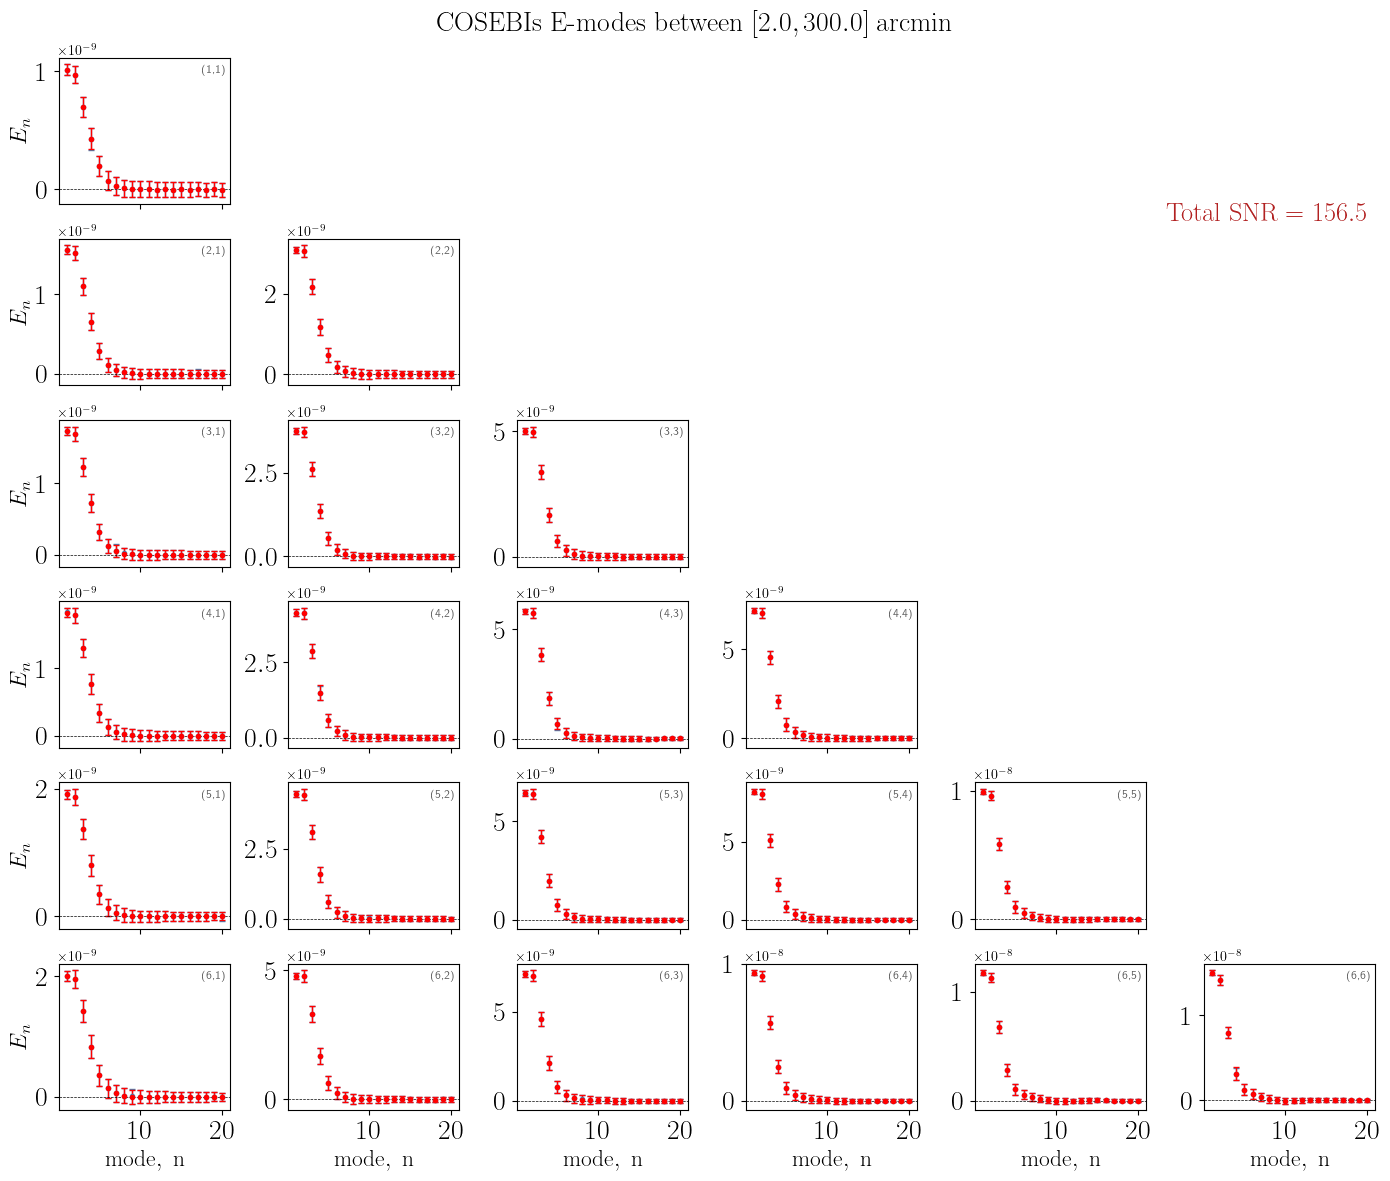

In [116]:
fontsi = 20


# Extract errorbars from covariance diagonal (E-mode block: first 420×420)
cov_diag = np.diag(cov[:420, :420])  # shape (420,)

# Reshape into (21 pairs, 20 modes) following the ordering
n_modes = 20
cov_per_pair = cov_diag.reshape(len(unique_pairs), n_modes)  # (21, 20)
En_per_pair = np.array([En[i, j, :] for i, j in unique_pairs])  # (21, 20)
En_per_pair_high_acc = np.array([En_high_acc[i, j, :] for i, j in unique_pairs])  # (21, 20)


err_per_pair = np.sqrt(cov_per_pair)  # 1-sigma errorbars

modes = np.arange(1, n_modes + 1)

# Build a lookup: (i,j) -> index in unique_pairs
pair_to_idx = {pair: k for k, pair in enumerate(unique_pairs)}

fig, axes = plt.subplots(n_tomo, n_tomo, figsize=(14, 12),
                         sharex=True)
fig.subplots_adjust(hspace=0.05, wspace=0.05)

for row in range(n_tomo):
    for col in range(n_tomo):
        ax = axes[row, col]
        # Only fill lower triangle + diagonal (i >= j, 0-based)
        if col > row:
            ax.axis("off")
            continue

        i, j = row, col  # tomo indices (0-based)
        # pair stored as (min, max)
        key = (min(i, j), max(i, j))
        k = pair_to_idx[key]

        En_k = En_per_pair[k]
        En_k_high_acc = En_per_pair_high_acc[k]
        err_k = err_per_pair[k]

        ax.errorbar(modes, En_k, yerr=err_k, fmt="o", ms=3,
                    lw=1, capsize=2, color="steelblue")
        ax.errorbar(modes, En_k_high_acc, yerr=err_k, fmt="o", ms=3,
                    lw=1, capsize=2, color="red")
        
        ax.axhline(0, color="k", lw=0.5, ls="--")
        ax.tick_params(labelsize=fontsi)

        # Axis labels only on edges
        if row == n_tomo - 1:
            ax.set_xlabel(r"$\mathrm{mode,\; n}$", fontsize=fontsi - 3)
        if col == 0:
            ax.set_ylabel("$E_n$", fontsize=fontsi - 3)

        # Panel label
        ax.text(0.97, 0.95, f"({i+1},{j+1})",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=8, color="0.4")
fig.text(0.98, 0.8, f"$\mathrm{{Total\;SNR}} = {snr:.1f}$",
    ha="right", va="bottom", fontsize=fontsi - 1,
    color="firebrick")
fig.suptitle(r"$\mathrm{COSEBIs\; E\textnormal{-}modes\;between\;[" + str(tmin) + "," + str(tmax) + "]\;\mathrm{arcmin}}$", fontsize=fontsi)
plt.tight_layout()
plt.savefig(f"corner_emodes_tmin{tmin}_tmax{tmax}.pdf", bbox_inches="tight")
plt.show()